# Graph Layout Optimization via Reinforcement Learning
## Ginger Agents — CS5180 Spring 2026
**Team:** Weiyi Mao, Hui Kong

This notebook documents the full pipeline:
1. Pre-compute topology embeddings
2. Train PPO agent
3. Evaluate on test set (SPC metric)
4. Visualize results

## 0. Setup & Imports

In [1]:
import os
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm

from stable_baselines3 import PPO
from env_fixed import GraphLayoutEnvFixed, MAX_NODES
from xing import XingLoss

print(f"PyTorch: {torch.__version__}")
print(f"Working dir: {os.getcwd()}")

PyTorch: 2.7.0
Working dir: /Users/mao/Downloads


## 1. Pre-compute Topology Embeddings
Compute 7 structural features per node (degree, clustering, betweenness, pagerank, etc.).
Only needs to run once — results saved to `rome_embeddings.pt`.

In [2]:
# Run precompute (skip if rome_embeddings.pt already exists)
if not os.path.exists("rome_embeddings.pt"):
    !python precompute_embeddings.py --data_path rome_gnn_data.pt
else:
    print("rome_embeddings.pt already exists, skipping.")

# Verify
emb_data = torch.load("rome_embeddings.pt", weights_only=False)
print(f"Embeddings loaded: {len(emb_data)} graphs")
print(f"Node feature shape: {emb_data[0]['node_emb'].shape}")
print(f"Features: [degree, clustering, betweenness, pagerank, avg_sp, local_density, triangles]")

rome_embeddings.pt already exists, skipping.
Embeddings loaded: 9976 graphs
Node feature shape: torch.Size([14, 7])
Features: [degree, clustering, betweenness, pagerank, avg_sp, local_density, triangles]


## 2. Load Embeddings & Training Graphs

In [3]:
# Load embeddings into dict
emb_dict = {}
for d in emb_data:
    emb_dict[d["graph_name"]] = {
        "node_emb": d["node_emb"],
        "graph_emb": d["graph_emb"],
    }
print(f"Embedding dict: {len(emb_dict)} graphs")

# Get training graph paths
rome_dir = "./rome"
train_paths = []
for fname in sorted(os.listdir(rome_dir)):
    if not fname.endswith(".graphml"):
        continue
    try:
        num = int(fname.split("grafo")[1].split(".")[0])
    except:
        continue
    if num > 9999:
        continue
    fpath = os.path.join(rome_dir, fname)
    G = nx.read_graphml(fpath)
    if G.number_of_nodes() <= MAX_NODES:
        train_paths.append(fpath)

print(f"Training graphs: {len(train_paths)}")

Embedding dict: 9976 graphs
Training graphs: 9872


## 3. Train PPO Agent

**Environment design:**
- State = [topology embedding (7d) + normalized coords (2d)] per node = [N, 9]
- Action = [node_selector, Δx, Δy]
- Reward = big bonus for new best crossing, penalty for making it worse
- Tracks best layout seen during episode
- move_scale = 2.0 (small precise adjustments)

In [4]:
# Create environment
env = GraphLayoutEnvFixed(
    train_paths,
    embeddings=emb_dict,
    max_steps=300,
    move_scale=2.0,
    patience=50,
)

print(f"Observation space: {env.observation_space.shape}")
print(f"Action space: {env.action_space.shape}")

Observation space: (903,)
Action space: (3,)


In [9]:
# Train PPO
TIMESTEPS = 2000000  # Change as needed: 500000 (fast), 2000000 (medium), 5000000 (best)

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=0.99,
    ent_coef=0.02,
    clip_range=0.2,
)

print(f"Training for {TIMESTEPS:,} timesteps...")
model.learn(total_timesteps=TIMESTEPS)
model.save("ppo_fixed")
print("Model saved → ppo_fixed.zip")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training for 2,000,000 timesteps...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 53.3     |
|    ep_rew_mean     | -1.38    |
| time/              |          |
|    fps             | 354      |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 52.4         |
|    ep_rew_mean          | -1.94        |
| time/                   |              |
|    fps                  | 293          |
|    iterations           | 2            |
|    time_elapsed         | 13           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0054740254 |
|    clip_fraction        | 0.06         |
|    clip_rang

## 4. Evaluate on Test Set (SPC Metric)

**SPC (Symmetric Percent Change):**
$$SPC = 100\% \times \frac{1}{N_t} \sum_{i} \frac{D_i - G_i}{\max(D_i, G_i)}$$

- $D_i$ = our PPO crossings on graph $i$
- $G_i$ = neato crossings on graph $i$  
- SPC < 0 means we beat neato (e.g., SPC = -20 means 20% better)

In [5]:
# Load model (if starting from here)
model = PPO.load("ppo_fixed")

# Get test graphs (10000-10100)
test_paths = []
for fname in sorted(os.listdir(rome_dir)):
    if not fname.endswith(".graphml"):
        continue
    try:
        num = int(fname.split("grafo")[1].split(".")[0])
    except:
        continue
    if 10000 <= num <= 10100:
        fpath = os.path.join(rome_dir, fname)
        G = nx.read_graphml(fpath)
        if G.number_of_nodes() <= MAX_NODES:
            test_paths.append(fpath)

print(f"Test graphs: {len(test_paths)}")

Test graphs: 99


In [6]:
model_path = "ppo_fixed.zip"

if os.path.exists(model_path):
    print("Founding exiting file - ppo_fixed, loading")
    model = PPO.load(model_path, env=env)

发现已存在的模型，正在加载...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [7]:
# Run evaluation on all test graphs
results = []

for gpath in tqdm(test_paths, desc="Evaluating"):
    graph_name = os.path.basename(gpath)
    
    env_test = GraphLayoutEnvFixed(
        [gpath], embeddings=emb_dict,
        max_steps=300, move_scale=2.0, patience=50,
    )
    
    obs, _ = env_test.reset()
    neato_crossings = env_test.initial_crossings
    history = [neato_crossings]
    
    done, truncated = False, False
    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env_test.step(action)
        history.append(info["crossings"])
    
    results.append({
        "graph_name": graph_name,
        "neato": neato_crossings,
        "ppo_best": info["best_crossings"],
        "improvement": info["improvement"],
        "history": history,
    })

print(f"\nEvaluated {len(results)} graphs")

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]


Evaluated 99 graphs


In [8]:
# Compute SPC
spc_values = []
for r in results:
    denom = max(r["ppo_best"], r["neato"])
    if denom > 0:
        spc_values.append((r["ppo_best"] - r["neato"]) / denom)
    else:
        spc_values.append(0.0)

spc = 100.0 * np.mean(spc_values)

wins = sum(1 for r in results if r["improvement"] > 0)
ties = sum(1 for r in results if r["improvement"] == 0)
losses = sum(1 for r in results if r["improvement"] < 0)

avg_neato = np.mean([r["neato"] for r in results])
avg_ppo = np.mean([r["ppo_best"] for r in results])

print("=" * 60)
print(f"  SPC = {spc:.2f}%  (negative = better than neato)")
print("=" * 60)
print(f"  Test graphs      : {len(results)}")
print(f"  Wins / Ties / Loss: {wins} / {ties} / {losses}")
print(f"  Win rate         : {100 * wins / len(results):.1f}%")
print(f"  Avg neato        : {avg_neato:.1f}")
print(f"  Avg PPO          : {avg_ppo:.1f}")
print("=" * 60)

  SPC = -0.43%  (negative = better than neato)
  Test graphs      : 99
  Wins / Ties / Loss: 7 / 92 / 0
  Win rate         : 7.1%
  Avg neato        : 29.1
  Avg PPO          : 29.0


## 5. Per-Graph Results Table

In [9]:
# Print all results
print(f"{'Graph Name':<35} {'neato':>6} {'PPO':>6} {'Δ':>5} {'Status':>6}")
print("-" * 65)
for r in sorted(results, key=lambda x: -x["improvement"]):
    imp = r["improvement"]
    status = "✓ WIN" if imp > 0 else ("= TIE" if imp == 0 else "✗ LOSS")
    print(f"{r['graph_name']:<35} {int(r['neato']):>6} {int(r['ppo_best']):>6} {int(imp):>+5} {status:>6}")

Graph Name                           neato    PPO     Δ Status
-----------------------------------------------------------------
grafo10097.95.graphml                   38     36    +2  ✓ WIN
grafo10099.94.graphml                  171    169    +2  ✓ WIN
grafo10003.40.graphml                   13     12    +1  ✓ WIN
grafo10042.39.graphml                   12     11    +1  ✓ WIN
grafo10049.39.graphml                    9      8    +1  ✓ WIN
grafo10084.97.graphml                  191    190    +1  ✓ WIN
grafo10089.37.graphml                   12     11    +1  ✓ WIN
grafo10000.38.graphml                   11     11    +0  = TIE
grafo10001.32.graphml                    0      0    +0  = TIE
grafo10002.40.graphml                    4      4    +0  = TIE
grafo10004.32.graphml                    4      4    +0  = TIE
grafo10005.39.graphml                   23     23    +0  = TIE
grafo10006.98.graphml                  125    125    +0  = TIE
grafo10007.31.graphml                    2      2   

## 6. Visualization

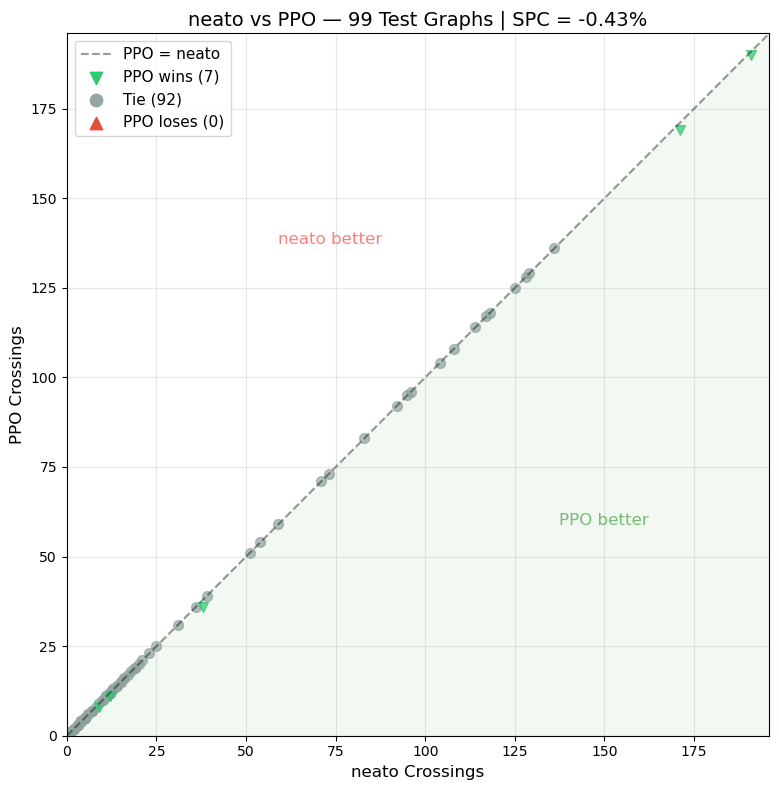

In [10]:
# PLOT 1: Scatter — neato vs PPO crossings
fig, ax = plt.subplots(figsize=(8, 8))

max_val = max(max(r["neato"] for r in results), max(r["ppo_best"] for r in results)) + 5
ax.plot([0, max_val], [0, max_val], "k--", alpha=0.4, label="PPO = neato")

for r in results:
    color = "#2ecc71" if r["improvement"] > 0 else ("#95a5a6" if r["improvement"] == 0 else "#e74c3c")
    marker = "v" if r["improvement"] > 0 else ("o" if r["improvement"] == 0 else "^")
    ax.scatter(r["neato"], r["ppo_best"], c=color, marker=marker, s=50, alpha=0.7)

ax.scatter([], [], c="#2ecc71", marker="v", s=80, label=f"PPO wins ({wins})")
ax.scatter([], [], c="#95a5a6", marker="o", s=80, label=f"Tie ({ties})")
ax.scatter([], [], c="#e74c3c", marker="^", s=80, label=f"PPO loses ({losses})")

ax.fill_between([0, max_val], [0, max_val], 0, alpha=0.05, color="green")
ax.text(max_val*0.7, max_val*0.3, "PPO better", fontsize=12, color="green", alpha=0.5)
ax.text(max_val*0.3, max_val*0.7, "neato better", fontsize=12, color="red", alpha=0.5)

ax.set_xlabel("neato Crossings", fontsize=12)
ax.set_ylabel("PPO Crossings", fontsize=12)
ax.set_title(f"neato vs PPO — {len(results)} Test Graphs | SPC = {spc:.2f}%", fontsize=14)
ax.legend(fontsize=11)
ax.set_aspect("equal")
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("scatter_neato_vs_ppo.png", dpi=150)
plt.show()

In [ ]:
# PLOT 2: Summary — Pie + Avg Crossings + SPC
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart
ax = axes[0]
ax.pie([wins, ties, losses],
       labels=[f"Win ({wins})", f"Tie ({ties})", f"Loss ({losses})"],
       colors=["#2ecc71", "#95a5a6", "#e74c3c"],
       autopct="%1.0f%%", startangle=90, textprops={"fontsize": 11})
ax.set_title("Win / Tie / Loss", fontsize=13)

# Avg crossings bar
ax = axes[1]
bars = ax.bar(["neato", "PPO (ours)"], [avg_neato, avg_ppo],
              color=["#e74c3c", "#2ecc71"], alpha=0.8, width=0.5)
for bar, val in zip(bars, [avg_neato, avg_ppo]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}", ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Avg Crossings")
ax.set_title("Average Crossings on Test Set", fontsize=13)
ax.grid(axis="y", alpha=0.3)

# SPC display
ax = axes[2]
ax.text(0.5, 0.55, f"SPC = {spc:.2f}%", ha="center", va="center",
        fontsize=28, fontweight="bold",
        color="#2ecc71" if spc < 0 else "#e74c3c",
        transform=ax.transAxes)
ax.text(0.5, 0.3, "Symmetric Percent Change", ha="center",
        fontsize=12, color="gray", transform=ax.transAxes)
ax.text(0.5, 0.18, "(negative = better than neato)", ha="center",
        fontsize=10, color="gray", transform=ax.transAxes)
ax.axis("off")
ax.set_title("Final Metric", fontsize=13)

plt.suptitle(f"PPO + Topology Embeddings vs neato", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("summary_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# PLOT 3: Bar chart of wins only
win_results = [r for r in results if r["improvement"] > 0]

if win_results:
    win_results.sort(key=lambda x: -x["improvement"])
    fig, ax = plt.subplots(figsize=(12, 5))
    
    names = [r["graph_name"].replace(".graphml", "") for r in win_results]
    neato_vals = [r["neato"] for r in win_results]
    ppo_vals = [r["ppo_best"] for r in win_results]
    
    x = np.arange(len(names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, neato_vals, width, label="neato", color="#e74c3c", alpha=0.8)
    bars2 = ax.bar(x + width/2, ppo_vals, width, label="PPO (ours)", color="#2ecc71", alpha=0.8)
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{int(bar.get_height())}", ha="center", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{int(bar.get_height())}", ha="center", fontsize=8, fontweight="bold")
    
    ax.set_ylabel("Edge Crossings")
    ax.set_title(f"Graphs Where PPO Beats neato ({len(win_results)} wins)", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("wins_bar_chart.png", dpi=150)
    plt.show()
else:
    print("No wins to plot.")

In [ ]:
# PLOT 4: Best win — crossing history
if win_results:
    best = win_results[0]  # already sorted by improvement
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axhline(y=best["neato"], color="red", linestyle="--",
               label=f'neato baseline ({int(best["neato"])})')
    ax.plot(best["history"], label="PPO", color="blue")
    
    best_step = np.argmin(best["history"])
    best_val = best["history"][best_step]
    ax.scatter([best_step], [best_val], color="green", s=100, zorder=5,
               label=f"best: {int(best_val)} (step {best_step})")
    
    ax.set_xlabel("Steps")
    ax.set_ylabel("Edge Crossings")
    ax.set_title(f"Best Improvement: {best['graph_name']}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.98,
            f"neato: {int(best['neato'])} → PPO: {int(best['ppo_best'])} (Δ = {int(best['improvement'])})",
            transform=ax.transAxes, fontsize=11, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    plt.tight_layout()
    plt.savefig("best_win_history.png", dpi=150)
    plt.show()
else:
    print("No wins to plot.")

## 7. Test on Specific Graph

In [ ]:
# Test on grafo4647 (teammate's test graph)
test_graph = "grafo4647.62.graphml"
test_path = os.path.join(rome_dir, test_graph)

env_single = GraphLayoutEnvFixed(
    [test_path], embeddings=emb_dict,
    max_steps=300, move_scale=2.0, patience=50,
)

obs, _ = env_single.reset()
neato_c = env_single.initial_crossings
hist = [neato_c]

done, truncated = False, False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env_single.step(action)
    hist.append(info["crossings"])

print(f"neato: {int(neato_c)} → PPO best: {int(info['best_crossings'])} (Δ = {int(info['improvement'])})")

# Plot
plt.figure(figsize=(10, 5))
plt.axhline(y=neato_c, color="red", linestyle="--", label=f"neato ({int(neato_c)})")
plt.plot(hist, label="PPO", color="blue")
best_s = np.argmin(hist)
plt.scatter([best_s], [hist[best_s]], color="green", s=100, zorder=5, label=f"best: {int(hist[best_s])}")
plt.xlabel("Steps")
plt.ylabel("Edge Crossings")
plt.title(f"PPO vs neato — {test_graph}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()